# Exercícios — Métricas de Classificação

**Tema:** Avaliação e Validação de Modelos › Métricas de Classificação

Resolva antes de olhar o gabarito. **Dificuldade:** 🟢 base · 🟡 aplicação ·
🔴 síntese

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import chi2
from sklearn.ensemble import HistGradientBoostingClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (roc_auc_score, average_precision_score, roc_curve, f1_score,
                             matthews_corrcoef)
from sklearn.model_selection import train_test_split

rng = np.random.default_rng(616)
plt.rcParams["axes.grid"] = True
plt.rcParams["grid.alpha"] = 0.3
AZUL, VERDE, VERMELHO, ROXO, AMBAR = "#1F5C8B", "#1E6B4F", "#9C2B2B", "#5B3E86", "#8A6100"
print("ambiente pronto")

ambiente pronto


---
## Dataset de trabalho: churn de uma operadora de telefonia

16.000 clientes, com cerca de 16% de cancelamento no trimestre seguinte.
Dois modelos candidatos já treinados — uma regressão logística e um
gradient boosting — produziram probabilidades para os 8.000 clientes do
conjunto de teste (`p_log` e `p_gb`).

In [2]:
n = 16000
meses = rng.exponential(24, n).clip(1, 120)
reclamacoes = rng.poisson(0.6, n)
fatura = rng.lognormal(np.log(90), 0.4, n)
uso_dados = rng.gamma(2, 3, n)
fidelidade = (rng.random(n) < 0.4).astype(int)
logit = (-1.4 - 0.035 * meses + 0.55 * reclamacoes + 0.008 * (fatura - 90)
         - 1.2 * fidelidade + 0.5 * (uso_dados < 2) + 0.4 * reclamacoes * (meses < 12)
         + rng.normal(0, 0.5, n))
churn = (rng.random(n) < 1 / (1 + np.exp(-logit))).astype(int)
X = np.column_stack([meses, reclamacoes, fatura, uso_dados, fidelidade])
X_tr, X_te, y_tr, y_te = train_test_split(X, churn, test_size=0.5, random_state=0, stratify=churn)
p_log = LogisticRegression(max_iter=3000).fit(X_tr, y_tr).predict_proba(X_te)[:, 1]
p_gb = HistGradientBoostingClassifier(max_iter=200, learning_rate=0.05, random_state=0) \
    .fit(X_tr, y_tr).predict_proba(X_te)[:, 1]
print(f"taxa de churn: {churn.mean():.1%} | teste: {len(y_te)} clientes, {y_te.sum()} churners")

taxa de churn: 16.4% | teste: 8000 clientes, 1308 churners


---
## Exercício 1 🟢 — A matriz na mão

Numa amostra de 1.000 clientes, com 60 churners, um modelo produziu
VP = 45, FN = 15, FP = 90, VN = 850. Calcule acurácia, precisão, recall,
especificidade, F1, acurácia balanceada e MCC. Depois calcule as mesmas
métricas para o modelo que diz "não vai cancelar" para todo mundo. Qual
métrica "prefere" o modelo inútil?

In [3]:
# --- sua resposta ---

### Gabarito 1

In [4]:
def metricas(vp, fn, fp, vn):
    n = vp + fn + fp + vn
    prec = vp / (vp + fp) if vp + fp else float("nan")
    rec, esp = vp / (vp + fn), vn / (vn + fp)
    denom = np.sqrt(float((vp + fp) * (vp + fn) * (vn + fp) * (vn + fn)))
    return {"acurácia": (vp + vn) / n, "precisão": prec, "recall": rec, "especificidade": esp,
            "F1": 2 * vp / (2 * vp + fp + fn), "acurácia balanceada": (rec + esp) / 2,
            "MCC": (vp * vn - fp * fn) / denom if denom else 0.0}

print(pd.DataFrame({"modelo": metricas(45, 15, 90, 850),
                    "sempre 'não cancela'": metricas(0, 60, 0, 940)}).round(3).to_string())

                     modelo  sempre 'não cancela'
acurácia              0.895                  0.94
precisão              0.333                   NaN
recall                0.750                  0.00
especificidade        0.904                  1.00
F1                    0.462                  0.00
acurácia balanceada   0.827                  0.50
MCC                   0.455                  0.00


**Por quê:** o modelo tem acurácia de 89,5%; o inútil, de **94%** —
a acurácia prefere o modelo que nunca encontra um churner, porque
acertar os 940 que ficam vale mais, na conta, do que encontrar 45 dos 60
que saem. Precisão (33%) e recall (75%) mostram o que o modelo faz; F1
(0,46), acurácia balanceada (0,83) e MCC (0,45) resumem esse desempenho
e dão zero (ou 0,5, na acurácia balanceada) para o modelo inútil.
O MCC: $(45 \cdot 850 - 90 \cdot 15)/\sqrt{135 \cdot 60 \cdot 940 \cdot 865} = 36.900/81.155 \approx 0{,}45$.

---
## Exercício 2 🟢 — O mesmo modelo, outra população

O modelo do exercício 1 tem recall de 75% e especificidade de 90,4%. O
time de marketing quer aplicá-lo (a) ao segmento de clientes com
fidelidade contratual, onde o churn é de apenas 2%, e (b) a um segmento de
planos pré-pagos, onde o churn é de 25%. Qual a precisão esperada em cada
um? Confira com uma simulação.

In [5]:
# --- sua resposta ---

### Gabarito 2

In [6]:
rec, esp = 45 / 60, 850 / 940
for prev in [0.02, 0.06, 0.25]:
    bayes = rec * prev / (rec * prev + (1 - esp) * (1 - prev))
    m = 500_000
    real = rng.random(m) < prev
    alarme = np.where(real, rng.random(m) < rec, rng.random(m) > esp)
    print(f"prevalência {prev:>4.0%}: precisão (Bayes) = {bayes:.3f} | "
          f"simulada = {(real & alarme).sum() / alarme.sum():.3f}")

prevalência   2%: precisão (Bayes) = 0.138 | simulada = 0.137
prevalência   6%: precisão (Bayes) = 0.333 | simulada = 0.331
prevalência  25%: precisão (Bayes) = 0.723 | simulada = 0.723


**Por quê:** pela fórmula de Bayes,
$\text{precisão} = \frac{0{,}75\,\pi}{0{,}75\,\pi + 0{,}096\,(1-\pi)}$. Com
$\pi = 2\%$, a precisão cai para cerca de 14% — de cada 7 clientes
contatados, 6 não iam cancelar. Com $\pi = 25\%$, sobe para cerca de 72%.
Nada no modelo mudou; a campanha de retenção no segmento fidelizado vai
gastar a maior parte do orçamento com quem já ia ficar.

---
## Exercício 3 🟡 — AUC por pares, AP, Gini, KS e lift

Para `p_log`: (a) estime a AUC sorteando 100 mil pares (um churner, um
não churner) e contando em quantos o churner tem a maior probabilidade;
compare com `roc_auc_score`. (b) Calcule AP e compare com a AP de um
modelo aleatório. (c) Calcule Gini e KS. (d) Qual o lift dos 10% de
clientes com maior probabilidade?

In [7]:
# --- sua resposta ---

### Gabarito 3

In [8]:
pos, neg = p_log[y_te == 1], p_log[y_te == 0]
i, j = rng.integers(0, len(pos), 100_000), rng.integers(0, len(neg), 100_000)
auc_pares = np.mean(pos[i] > neg[j]) + 0.5 * np.mean(pos[i] == neg[j])
auc = roc_auc_score(y_te, p_log)
print(f"(a) AUC por pares = {auc_pares:.4f} | roc_auc_score = {auc:.4f}")
print(f"(b) AP = {average_precision_score(y_te, p_log):.3f} | modelo aleatório = {y_te.mean():.3f}")
fpr, tpr, _ = roc_curve(y_te, p_log)
print(f"(c) Gini = {2 * auc - 1:.3f} | KS = {np.max(tpr - fpr):.3f}")
top10 = np.argsort(-p_log)[: len(p_log) // 10]
print(f"(d) taxa de churn no top 10% = {y_te[top10].mean():.3f} -> lift = {y_te[top10].mean() / y_te.mean():.2f}")

(a) AUC por pares = 0.7633 | roc_auc_score = 0.7640
(b) AP = 0.417 | modelo aleatório = 0.164
(c) Gini = 0.528 | KS = 0.397
(d) taxa de churn no top 10% = 0.490 -> lift = 3.00


**Por quê:** a AUC é, por definição, a probabilidade de ordenar certo um
par — a amostragem de pares converge para ela. A AP deve ser lida contra
a prevalência (a AP do modelo aleatório): o modelo multiplica essa base
várias vezes. Gini e KS são a mesma separação em outras escalas, e o lift
do primeiro decil é o número que o time de marketing entende: contatar os
10% de maior risco rende várias vezes mais churners por ligação do que
ligar ao acaso.

---
## Exercício 4 🟡 — O limiar da campanha de retenção

Cada cliente contatado recebe uma oferta que custa R$ 50. Se o cliente
ia cancelar, a oferta o retém em 30% dos casos, preservando R$ 400 de
margem. Se não ia cancelar, os R$ 50 são gastos à toa. Não contatar não
custa nada.

(a) Escreva o lucro esperado de contatar um cliente com probabilidade $p$
de churn e derive o limiar ótimo. (b) Com `p_log`, trace o lucro total em
função do limiar e compare o limiar empírico com o teórico. (c) Qual o
lucro nos limiares 0,5 e de F1 máximo?

In [9]:
# --- sua resposta ---

### Gabarito 4

(a) lucro esperado = 70p - 50(1-p) > 0  <=>  p > 50/120 = 0.417
(b) limiar empírico = 0.440 -> lucro R$ 9,190
(c) limiar 0,5 (0.500) -> lucro R$ 7,340
(c) limiar F1 máximo (0.200) -> lucro R$ -24,040


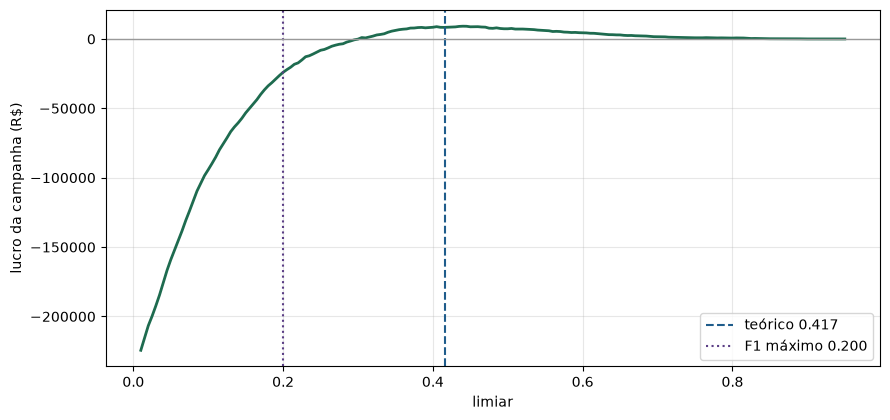

In [10]:
GANHO_VP, CUSTO_FP = 0.30 * 400 - 50, 50          # +70 se era churner, -50 se não era
t_teo = CUSTO_FP / (GANHO_VP + CUSTO_FP)

def lucro(p, y, t):
    contata = p >= t
    return GANHO_VP * np.sum(contata & (y == 1)) - CUSTO_FP * np.sum(contata & (y == 0))

limiares = np.linspace(0.01, 0.95, 189)
lucros = np.array([lucro(p_log, y_te, t) for t in limiares])
t_emp = limiares[np.argmax(lucros)]
t_f1 = limiares[int(np.argmax([f1_score(y_te, (p_log >= t).astype(int)) for t in limiares]))]
print(f"(a) lucro esperado = 70p - 50(1-p) > 0  <=>  p > 50/120 = {t_teo:.3f}")
print(f"(b) limiar empírico = {t_emp:.3f} -> lucro R$ {lucros.max():,.0f}")
for nome, t in [("0,5", 0.5), ("F1 máximo", t_f1)]:
    print(f"(c) limiar {nome} ({t:.3f}) -> lucro R$ {lucro(p_log, y_te, t):,.0f}")

fig, ax = plt.subplots(figsize=(9, 4.3))
ax.plot(limiares, lucros, color=VERDE, lw=2)
ax.axvline(t_teo, color=AZUL, ls="--", label=f"teórico {t_teo:.3f}")
ax.axvline(t_f1, color=ROXO, ls=":", label=f"F1 máximo {t_f1:.3f}")
ax.axhline(0, color="#999999", lw=1)
ax.set_xlabel("limiar"); ax.set_ylabel("lucro da campanha (R$)"); ax.legend()
plt.tight_layout(); plt.show()

**Por quê:** contatar dá $0{,}30 \cdot 400 - 50 = 70$ reais se o cliente
ia cancelar e $-50$ se não ia; o lucro esperado $70p - 50(1-p)$ é
positivo para $p > 50/120 \approx 0{,}417$. Esse é o limiar do custo
esperado, $C_{FP}/(C_{FP} + \text{ganho}_{VP})$, e o empírico fica perto
dele porque a logística está razoavelmente calibrada. O limiar de F1
máximo contata gente demais: cada contato com probabilidade abaixo de
0,417 tem lucro esperado **negativo**, e a campanha paga por isso.

---
## Exercício 5 🔴 — Qual modelo colocar em produção?

O time precisa escolher entre `p_log` e `p_gb`. O call center consegue
ligar para **600 clientes** no trimestre. Monte uma recomendação com:
(a) ROC-AUC e AP de cada modelo; (b) o lucro da campanha de cada um com
as 600 ligações (os 600 de maior probabilidade); (c) um intervalo de 95%,
por bootstrap **pareado**, para a diferença de lucro entre os modelos;
(d) o teste de McNemar sobre as decisões "ligar/não ligar" nesse ponto de
operação. Qual você recomenda, e com que grau de confiança?

In [11]:
# --- sua resposta ---

### Gabarito 5

In [12]:
K = 600
def lucro_top_k(p, y, k=K):
    top = np.argsort(-p)[:k]
    return GANHO_VP * y[top].sum() - CUSTO_FP * (k - y[top].sum())

for nome, pp in [("logística", p_log), ("boosting", p_gb)]:
    print(f"(a/b) {nome:>9s}: AUC={roc_auc_score(y_te, pp):.4f} | AP={average_precision_score(y_te, pp):.4f} | "
          f"lucro com {K} ligações = R$ {lucro_top_k(pp, y_te):,.0f}")

difs = []
for b in range(2000):
    idx = rng.integers(0, len(y_te), len(y_te))
    k_b = K  # mesma capacidade em cada reamostra
    difs.append(lucro_top_k(p_gb[idx], y_te[idx], k_b) - lucro_top_k(p_log[idx], y_te[idx], k_b))
lo, hi = np.percentile(difs, [2.5, 97.5])
print(f"(c) diferença de lucro (boosting - logística): R$ {np.mean(difs):,.0f}, IC 95% [{lo:,.0f}; {hi:,.0f}]")

liga_log = np.zeros(len(y_te), bool); liga_log[np.argsort(-p_log)[:K]] = True
liga_gb = np.zeros(len(y_te), bool); liga_gb[np.argsort(-p_gb)[:K]] = True
acerto_log, acerto_gb = liga_log == (y_te == 1), liga_gb == (y_te == 1)
b_, c_ = np.sum(acerto_gb & ~acerto_log), np.sum(~acerto_gb & acerto_log)
est = (abs(b_ - c_) - 1) ** 2 / (b_ + c_)
print(f"(d) McNemar: boosting acerta e logística erra = {b_}, o contrário = {c_}, "
      f"p-valor = {chi2.sf(est, 1):.4f}")

(a/b) logística: AUC=0.7640 | AP=0.4171 | lucro com 600 ligações = R$ 8,280


(a/b)  boosting: AUC=0.7433 | AP=0.3905 | lucro com 600 ligações = R$ 6,120


(c) diferença de lucro (boosting - logística): R$ -2,144, IC 95% [-4,560; 240]
(d) McNemar: boosting acerta e logística erra = 197, o contrário = 233, p-valor = 0.0914


**Como avaliar sua resposta:** poderia se esperar que o boosting
vencesse — os dados têm uma interação (reclamações pesam mais em clientes
novos) que a logística sem termos de interação não captura. Não é o que
acontece: a logística tem AUC e AP maiores e mais lucro com as 600
ligações. Com hiperparâmetros padrão e 8.000 exemplos, o ganho do
boosting com a interação não compensa a variância extra que ele traz (o
tema do módulo 4, viés e variância).

O que decide, porém, é a **incerteza** da diferença de lucro. O bootstrap
tem de ser **pareado** — a mesma reamostra de clientes para os dois
modelos —, porque os dois são avaliados nos mesmos clientes e seus erros
são correlacionados. Aqui o intervalo de 95% da diferença **inclui zero**
e o McNemar dá p-valor perto de 0,09: a vantagem da logística é
plausível, mas não está demonstrada com esta amostra. A recomendação
defensável é a logística — não porque ela vença com confiança
estatística, mas porque ela empata ou vence **e** é mais simples de
explicar, monitorar e auditar. Uma recomendação que dissesse "o boosting
tem AUC 0,02 menor, então é pior" estaria certa na conclusão e errada no
raciocínio.

---
## Fechamento

- Acurácia premia o modelo inútil em dados desbalanceados; MCC, F1 e
  acurácia balanceada não.
- A precisão viaja mal entre populações; recall e especificidade viajam
  bem.
- AUC é probabilidade de ordenar pares; Gini, KS e lift são a mesma ideia
  em outras escalas.
- O limiar sai do custo esperado (ou da capacidade), não de 0,5 nem do F1.
- Escolher entre modelos: métrica de negócio no ponto de operação, com
  intervalo de confiança pareado.

→ Próximo módulo: **Métricas de Regressão** — cada métrica otimiza um
comportamento diferente do modelo.